# Use Case 4 — Critical Path & Bottleneck Analysis

**Goal:** Identify the critical path in the EPC project using PRECEDES relations, and find scheduling bottlenecks by discipline and permit type  
**Neo4j:** `bolt://172.22.43.151:7687`  
**Prerequisite:** `import_graph_real.py` must have been run

## Questions answered:
1. What is the **critical path** (longest PRECEDES chain)?
2. Which **disciplines** concentrate the most constrained steps?
3. Which **permit types** create the most downstream dependencies (bottlenecks)?
4. Which **activities** lie on the critical path?

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from neo4j import GraphDatabase
import os
import warnings
warnings.filterwarnings('ignore')

NEO4J_URI      = 'bolt://172.22.43.151:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'your_password'

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def run_query(cypher, **params):
    with driver.session() as s:
        result = s.run(cypher, **params)
        return pd.DataFrame([r.data() for r in result])

os.makedirs('../../experiments/UseCase4', exist_ok=True)
print('✅ Connected to Neo4j')

✅ Connected to Neo4j


/home/obiaggi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Q5 — Critical Path (Longest PRECEDES Chain)

In [2]:
cp = run_query('''
    MATCH path = (start:Step)-[:PRECEDES*..30]->(end:Step)
    WHERE NOT ()-[:PRECEDES]->(start)
      AND NOT (end)-[:PRECEDES]->()
    WITH path, length(path) AS depth
    ORDER BY depth DESC
    LIMIT 1
    RETURN [n IN nodes(path) | n.name]        AS step_names,
           [n IN nodes(path) | n.activity_id] AS activity_ids,
           [n IN nodes(path) | n.permit_type] AS permit_types,
           [n IN nodes(path) | n.id]          AS step_ids,
           depth
''')

if len(cp) > 0:
    depth       = cp['depth'].iloc[0]
    step_names  = cp['step_names'].iloc[0]
    activity_ids= cp['activity_ids'].iloc[0]
    permit_types= cp['permit_types'].iloc[0]
    print(f'Critical path length: {depth} steps')
    print()
    print(f'{"Step":<4} {"Activity":<12} {"Permit":<18} {"Name"}')
    print('-'*70)
    for i, (n, a, p) in enumerate(zip(step_names, activity_ids, permit_types)):
        print(f'{i+1:<4} {a:<12} {p:<18} {n}')
else:
    print('⚠️  No PRECEDES chains found — check import')

Critical path length: 18 steps

Step Activity     Permit             Name
----------------------------------------------------------------------
1    ME.CT        general_work       General Activities
2    ME.CT        general_work       Structure & Stairs assembly
3    ME.CT        general_work       Fan deck & Handrails Assembly
4    ME.CT        general_work       FRP Main header Pipe Assembly
5    ME.CT        general_work       Cladding & Partition walls Assembly
6    ME.CT        general_work       Ladder assembly
7    ME.CT        general_work       Filling assembly
8    ME.CT        general_work       Distribution assembly
9    ME.CT        general_work       Drift eliminators assembly
10   ME.CT        general_work       Mechanical EQ assembly
11   ME.CT        general_work       Fan stacks assembly
12   ME.CT        general_work       Lubrication assembly
13   ME.CT        general_work       Trap Door/Inspection Ladder & Mech Gangway Assembly
14   ME.CT        general_work   

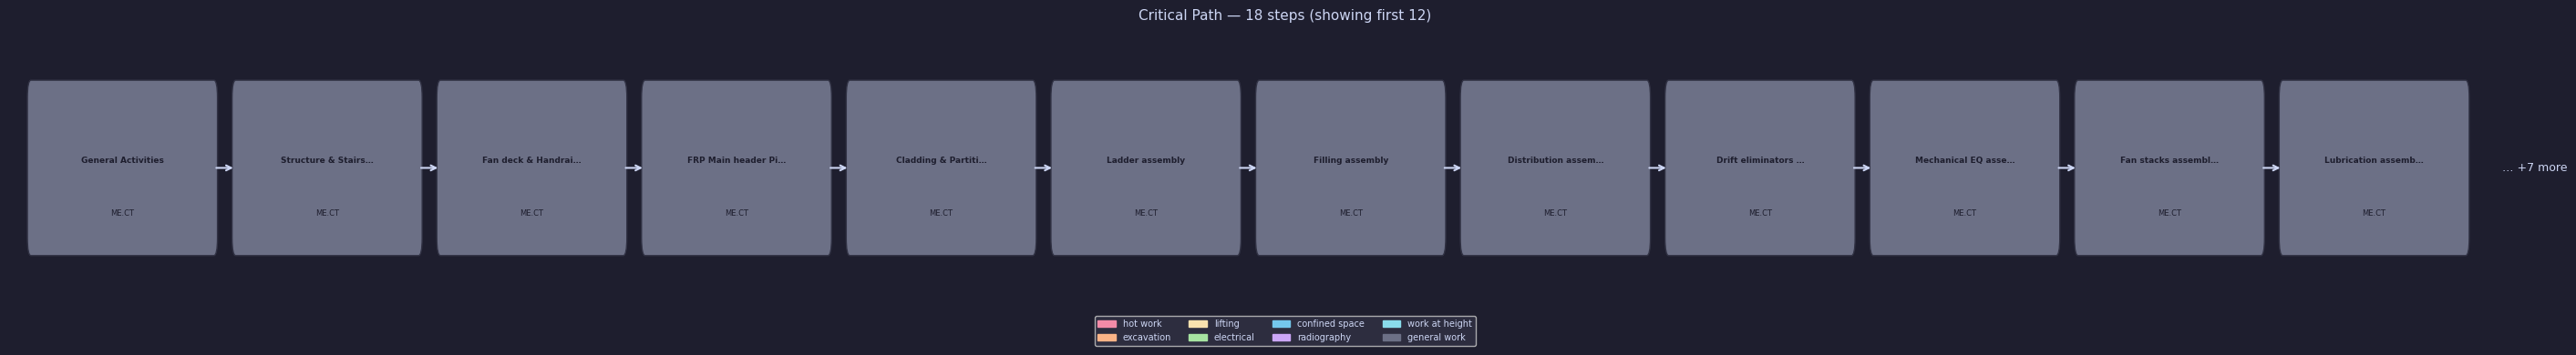

In [3]:
PERMIT_COLORS = {
    'hot_work':       '#f38ba8',
    'excavation':     '#fab387',
    'lifting':        '#f9e2af',
    'electrical':     '#a6e3a1',
    'confined_space': '#74c7ec',
    'radiography':    '#cba6f7',
    'work_at_height': '#89dceb',
    'general_work':   '#6c7086',
}

if len(cp) > 0:
    n_steps = len(step_names)
    fig, ax = plt.subplots(figsize=(max(14, n_steps * 1.5), 4))
    fig.patch.set_facecolor('#1e1e2e')
    ax.set_facecolor('#181825')
    ax.axis('off')

    show_steps = step_names[:12]  # limit display for readability
    show_acts  = activity_ids[:12]
    show_perms = permit_types[:12]

    for i, (name, act, perm) in enumerate(zip(show_steps, show_acts, show_perms)):
        color = PERMIT_COLORS.get(perm, '#cdd6f4')
        x = i * 2.8
        ax.add_patch(mpatches.FancyBboxPatch(
            (x, 0.3), 2.5, 0.4,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='#313244'
        ))
        short_name = name[:18] + '…' if len(name) > 18 else name
        ax.text(x+1.25, 0.52, short_name,
                ha='center', va='center', color='#1e1e2e', fontsize=6.5, fontweight='bold')
        ax.text(x+1.25, 0.37, act,
                ha='center', va='center', color='#1e1e2e', fontsize=6)
        if i < len(show_steps)-1:
            ax.annotate('', xy=(x+2.8, 0.5), xytext=(x+2.5, 0.5),
                        arrowprops=dict(arrowstyle='->', color='#cdd6f4', lw=1.5))

    if n_steps > 12:
        ax.text(len(show_steps)*2.8 + 0.2, 0.5, f'… +{n_steps-12} more',
                va='center', color='#cdd6f4', fontsize=9)

    legend_patches = [mpatches.Patch(color=c, label=p.replace('_',' '))
                      for p, c in PERMIT_COLORS.items()]
    ax.legend(handles=legend_patches, loc='lower center', ncol=4,
              facecolor='#313244', labelcolor='#cdd6f4', fontsize=7,
              bbox_to_anchor=(0.5, -0.15))

    ax.set_xlim(-0.3, len(show_steps)*2.8 + 1)
    ax.set_ylim(0.1, 0.9)
    ax.set_title(f'Critical Path — {depth} steps (showing first {min(12,n_steps)})',
                 color='#cdd6f4', fontsize=11)
    plt.tight_layout()
    plt.savefig('../../experiments/UseCase4/critical_path.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. Q6 — Bottleneck by Discipline

In [4]:
disc_bottleneck = run_query('''
    MATCH (act:Activity)-[:HAS_STEP]->(s:Step)-[:REQUIRES_PERMIT]->(wp:WorkPermit)
    RETURN act.discipline AS discipline,
           wp.id          AS permit,
           count(s)       AS n_steps
    ORDER BY discipline, n_steps DESC
''')

print('Steps per discipline per permit type:')
print(disc_bottleneck.pivot_table(
    index='discipline', columns='permit', values='n_steps', fill_value=0
).to_string())

Steps per discipline per permit type:
permit      confined_space  electrical  excavation  general_work  hot_work  lifting  radiography  work_at_height
discipline                                                                                                      
BU                     0.0        22.0        28.0         107.0       0.0      2.0          0.0            31.0
CI                     7.0         0.0       104.0         381.0       6.0      7.0          0.0            58.0
CO                     0.0         0.0         0.0          69.0       0.0      0.0          0.0             0.0
EL                     1.0         6.0         0.0          61.0       1.0      1.0          0.0             0.0
FP                     0.0         0.0         0.0           4.0       0.0      0.0          0.0             2.0
HV                     0.0         1.0         0.0          14.0       0.0      0.0          0.0             0.0
IN                     0.0         8.0         1.0        

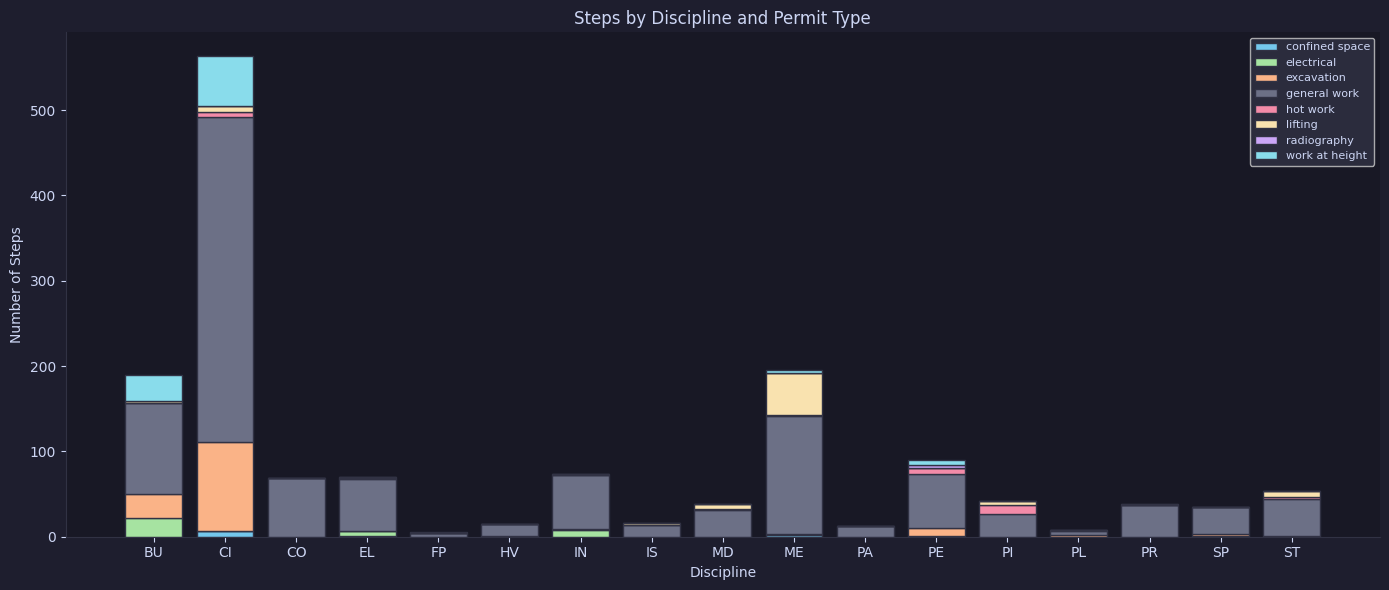

In [5]:
pivot = disc_bottleneck.pivot_table(
    index='discipline', columns='permit', values='n_steps', fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#181825')

bottom = np.zeros(len(pivot))
for permit in pivot.columns:
    color = PERMIT_COLORS.get(permit, '#cdd6f4')
    ax.bar(pivot.index, pivot[permit], bottom=bottom,
           color=color, edgecolor='#313244', label=permit.replace('_',' '))
    bottom += pivot[permit].values

ax.set_title('Steps by Discipline and Permit Type', color='#cdd6f4', fontsize=12)
ax.set_xlabel('Discipline', color='#cdd6f4')
ax.set_ylabel('Number of Steps', color='#cdd6f4')
ax.tick_params(colors='#cdd6f4')
ax.legend(loc='upper right', facecolor='#313244', labelcolor='#cdd6f4', fontsize=8)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax.spines[spine].set_color('#313244')

plt.tight_layout()
plt.savefig('../../experiments/UseCase4/bottleneck_discipline.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Q7 — Most Blocking Steps (Highest Downstream Count)

In [6]:
blocking = run_query('''
    MATCH (s:Step)-[:PRECEDES*1..30]->(downstream:Step)
    WITH s, count(downstream) AS blocks
    ORDER BY blocks DESC
    LIMIT 10
    MATCH (s)-[:REQUIRES_PERMIT]->(wp:WorkPermit)
    RETURN s.id AS step_id, s.name AS step_name,
           s.activity_id AS activity, wp.id AS permit, blocks
    ORDER BY blocks DESC
''')

print('Top 10 most blocking steps:')
print(blocking.to_string(index=False))

Top 10 most blocking steps:
     step_id                                     step_name activity         permit  blocks
BU.BR.AR_S01              Formworks in Cable gallery walls BU.BR.AR   general_work   57341
BU.BR.AR_S01              Formworks in Cable gallery walls BU.BR.AR work_at_height   57341
BU.BR.AR_S02       Reinforcing bars in Cable gallery walls BU.BR.AR   general_work   28669
BU.BR.AR_S03    Reinforced Concrete in Cable gallery walls BU.BR.AR   general_work   14333
BU.BR.AR_S04            Formworks in Electrical room walls BU.BR.AR   general_work    7165
BU.BR.AR_S04            Formworks in Electrical room walls BU.BR.AR     electrical    7165
BU.BR.AR_S05  Acid resistant ceramic tiles on battery room BU.BR.AR   general_work    3581
BU.BR.AR_S05  Acid resistant ceramic tiles on battery room BU.BR.AR     electrical    3581
BU.BR.AR_S06  Reinforced Concrete in Electrical room walls BU.BR.AR     electrical    1789
BU.BR.AR_S06  Reinforced Concrete in Electrical room walls BU.

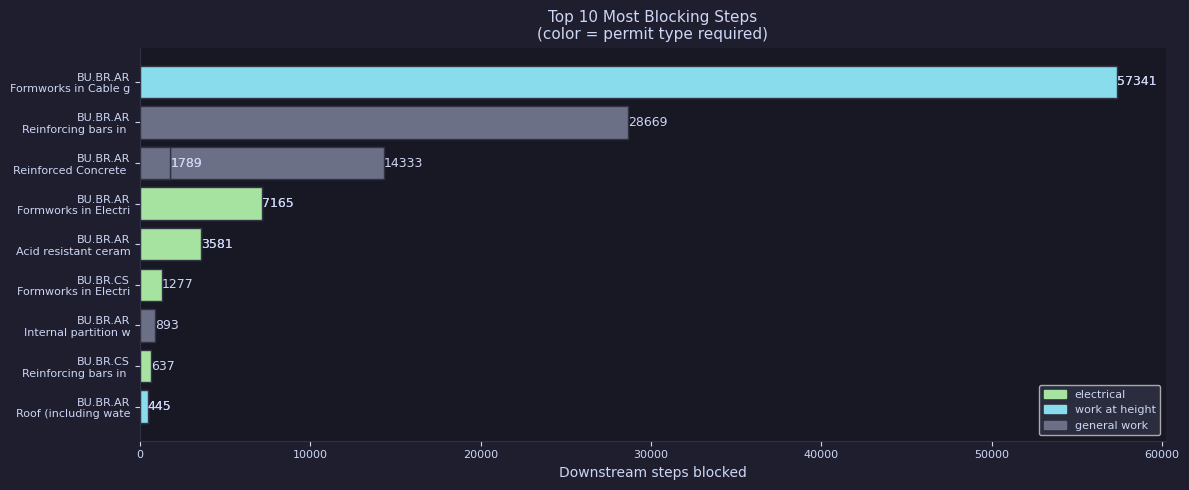

In [7]:
if len(blocking) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#1e1e2e')
    ax.set_facecolor('#181825')

    colors = [PERMIT_COLORS.get(p, '#cdd6f4') for p in blocking['permit']]
    labels = [f"{row['activity']}\n{row['step_name'][:20]}" for _, row in blocking.iterrows()]

    bars = ax.barh(labels, blocking['blocks'], color=colors, edgecolor='#313244')
    for bar, val in zip(bars, blocking['blocks']):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                str(val), va='center', color='#cdd6f4', fontsize=9)

    ax.set_xlabel('Downstream steps blocked', color='#cdd6f4')
    ax.set_title('Top 10 Most Blocking Steps\n(color = permit type required)',
                 color='#cdd6f4', fontsize=11)
    ax.tick_params(colors='#cdd6f4', labelsize=8)
    ax.invert_yaxis()
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
    for spine in ['bottom','left']: ax.spines[spine].set_color('#313244')

    legend_patches = [mpatches.Patch(color=c, label=p.replace('_',' '))
                      for p, c in PERMIT_COLORS.items()
                      if p in blocking['permit'].values]
    ax.legend(handles=legend_patches, facecolor='#313244', labelcolor='#cdd6f4', fontsize=8)

    plt.tight_layout()
    plt.savefig('../../experiments/UseCase4/bottleneck_steps.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Q8 — Activities on Critical Path

In [8]:
cp_activities = run_query('''
    MATCH path = (start:Step)-[:PRECEDES*..30]->(end:Step)
    WHERE NOT ()-[:PRECEDES]->(start)
      AND NOT (end)-[:PRECEDES]->()
    WITH path, length(path) AS depth
    ORDER BY depth DESC
    LIMIT 5
    UNWIND nodes(path) AS s
    MATCH (act:Activity)-[:HAS_STEP]->(s)
    RETURN DISTINCT act.id AS activity_id, act.name AS activity_name,
                    act.discipline AS discipline, depth
    ORDER BY depth DESC, discipline
''')

print('Activities on top-5 critical paths:')
print(cp_activities.to_string(index=False))

Activities on top-5 critical paths:
activity_id                                   activity_name discipline  depth
      ME.CT                          Cooling Tower Erection         ME     18
     CI.TF1                  Tanks Ring Concrete Foundation         CI     13
     ME.TK3                    LPG Tanks Metal Construction         ME     13
   BU.PC.AR                     Installation & Architecture         BU     12
     CI.DM2 Drainage Man Holes & Catchbasins (Cast in Situ)         CI     12


## 5. Summary

| Analysis | Key Finding |
|---|---|
| Critical path length | see Q5 output |
| Most constrained discipline | see Q6 heatmap |
| Most blocking permit type | see Q7 chart |
| Activities on critical path | see Q8 output |

**Tesi key point:** the PRECEDES graph enables scheduling analysis that goes beyond what a flat activity list can provide — the TKG structure directly encodes sequencing constraints and allows graph algorithms (longest path, centrality) to identify project risk.

In [9]:
driver.close()
print('✅ Done — results saved to experiments/UseCase4/')

✅ Done — results saved to experiments/UseCase4/
